In [1]:
# Cell: imports + load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# sesuaikan path jika perlu
DATA_PATH = "data-bank.csv"
df = pd.read_csv(DATA_PATH)
pd.set_option('display.max_columns', None)
df.shape, df.head()


((6819, 96),
    Bankrupt?   ROA(C) before interest and depreciation before interest  \
 0          1                                           0.370594          
 1          1                                           0.464291          
 2          1                                           0.426071          
 3          1                                           0.399844          
 4          1                                           0.465022          
 
     ROA(A) before interest and % after tax  \
 0                                 0.424389   
 1                                 0.538214   
 2                                 0.499019   
 3                                 0.451265   
 4                                 0.538432   
 
     ROA(B) before interest and depreciation after tax  \
 0                                           0.405750    
 1                                           0.516730    
 2                                           0.472295    
 3                 

In [2]:
# Cell: data understanding
print("Columns:", len(df.columns))
print("Sample head:")
display(df.head())

# Target column detection (manually set if needed)
target_col = 'Bankrupt?'   # dataset Anda menggunakan 'Bankrupt?' sebagai kolom target
print("Target value counts:")
display(df[target_col].value_counts())
print("Target proportion:")
display(df[target_col].value_counts(normalize=True))


Columns: 96
Sample head:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

Target value counts:


Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Target proportion:


Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

Bankrupt?                                                   1.000000
 Net Income to Total Assets                                 0.315457
 ROA(A) before interest and % after tax                     0.282941
 ROA(B) before interest and depreciation after tax          0.273051
 ROA(C) before interest and depreciation before interest    0.260807
 Net worth/Assets                                           0.250161
 Debt ratio %                                               0.250161
 Persistent EPS in the Last Four Seasons                    0.219560
 Retained Earnings to Total Assets                          0.217779
 Net profit before tax/Paid-in capital                      0.207857
 Per Share Net profit before tax (Yuan ¥)                   0.201395
 Current Liability to Assets                                0.194494
 Working Capital to Total Assets                            0.193083
 Net Income to Stockholder's Equity                         0.180987
 Borrowing dependency             

Top features (by absolute corr): ['Bankrupt?', ' Net Income to Total Assets', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' ROA(C) before interest and depreciation before interest', ' Net worth/Assets']


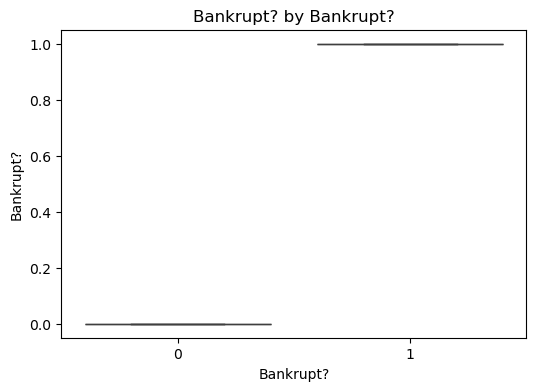

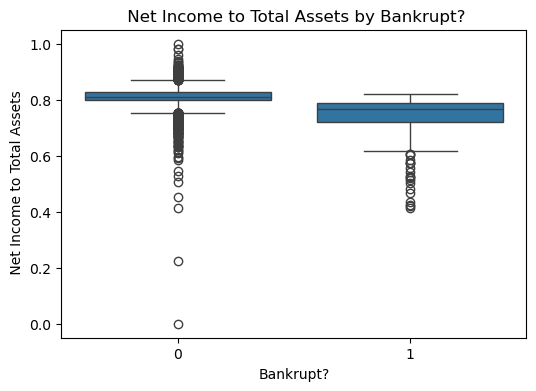

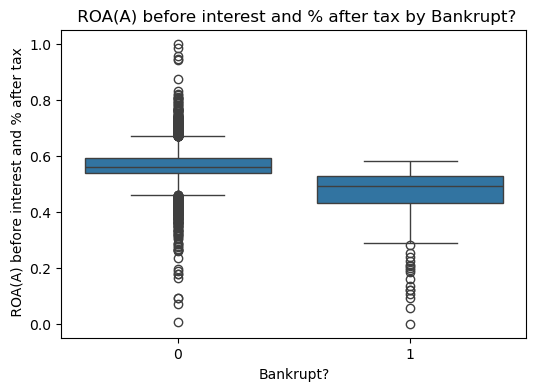

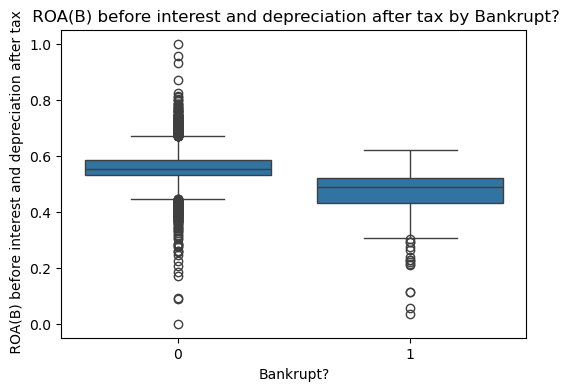

In [3]:
# Cell: EDA - correlation with target and visualizations
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric:
    numeric.remove(target_col)

# correlation with target
corrs = df[numeric + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
display(corrs.head(20))

# top features to plot
top_feats = corrs.index[0:6].tolist()
print("Top features (by absolute corr):", top_feats)

# Boxplots of top features vs target
for feat in top_feats[:4]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=feat, data=df)
    plt.title(f"{feat} by {target_col}")
    plt.show()


In [4]:
# Cell: data preparation
X = df[numeric].copy()
y = df[target_col].copy()

# Impute
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X_imp.columns)

# Train-test split (stratify)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Train counts:", y_train.value_counts().to_dict())

# Handle imbalance: try SMOTE if available, else simple oversample
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print("Used SMOTE, new counts:", pd.Series(y_res).value_counts().to_dict())
except Exception as e:
    print("imblearn not available or failed:", e)
    # simple random oversample minority
    from sklearn.utils import resample
    train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
    majority_class = y_train.mode()[0]
    df_major = train_df[train_df[target_col]==majority_class]
    df_minor = train_df[train_df[target_col]!=majority_class]
    df_minor_up = resample(df_minor, replace=True, n_samples=len(df_major), random_state=42)
    df_bal = pd.concat([df_major, df_minor_up])
    X_res = df_bal.drop(columns=[target_col])
    y_res = df_bal[target_col]
    print("Used simple oversampling, new counts:", y_res.value_counts().to_dict())


Train counts: {0: 5279, 1: 176}
imblearn not available or failed: No module named 'imblearn'
Used simple oversampling, new counts: {0.0: 5279, 1.0: 742}


In [ ]:
# Safe modelling cell: cek y_res, bersihkan, lalu fit models
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- 1) Safety checks and cleaning for y_res ---
# Aturan: y_res harus 1D array/Series, tidak mengandung NaN, dan panjangnya sesuai X_res.
print("X_res shape:", getattr(X_res, "shape", None))
print("y_res type:", type(y_res))
# Convert y_res to pandas Series if needed
import pandas as pd
if not isinstance(y_res, pd.Series):
    try:
        y_res = pd.Series(np.asarray(y_res).ravel())
    except Exception:
        y_res = pd.Series(y_res)

# Count NaN in y_res
nan_count = y_res.isna().sum()
print("NaN count in y_res:", nan_count)
if nan_count > 0:
    # If NaN exist, show value counts and drop NaNs (or you could impute if appropriate)
    print("Value counts (including NaN):")
    display(y_res.value_counts(dropna=False))
    # Drop rows with NaN in y_res and corresponding X_res rows
    non_na_idx = y_res.dropna().index
    print("Dropping NaN entries from training set:", len(y_res) - len(non_na_idx), "rows")
    y_res = y_res.loc[non_na_idx].reset_index(drop=True)
    if isinstance(X_res, pd.DataFrame):
        X_res = X_res.loc[non_na_idx].reset_index(drop=True)
    else:
        X_res = pd.DataFrame(X_res).iloc[non_na_idx].reset_index(drop=True)

# Ensure lengths match
if len(X_res) != len(y_res):
    raise ValueError(f"After cleaning lengths mismatch: X_res {len(X_res)} vs y_res {len(y_res)}")

# Force integer labels and no weird types
try:
    y_res = y_res.astype(int)
except Exception:
    # if cannot cast to int, keep as numeric
    y_res = pd.to_numeric(y_res)

print("Clean y_res value counts:", y_res.value_counts().to_dict())

# --- 2) Final safety: make sure X_test / y_test are compatible types for evaluation ---
# If X_test was transformed previously it's fine; ensure y_test is 1D numeric
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:,0]
y_test = pd.Series(y_test).reset_index(drop=True)

# --- 3) Define models and fit ---
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
}

fitted = {}
for name, m in models.items():
    print("\nTraining:", name)
    # Fit may still error if X_res contains NaN/infinite values. Quick check:
    if np.isfinite(X_res.values).all() is False:
        raise ValueError("X_res contains NaN or infinite values. Please impute/clean X_res before training.")
    m.fit(X_res, y_res)
    fitted[name] = m

    # Evaluate
    y_pred = m.predict(X_test)
    print("==", name, "report ==")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    # ROC AUC if predict_proba available and binary
    try:
        if hasattr(m, "predict_proba"):
            score = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
            print("ROC AUC:", score)
    except Exception as e:
        print("ROC AUC not available or failed:", e)


X_res shape: (10558, 95)
y_res type: <class 'pandas.core.series.Series'>
NaN count in y_res: 4537
Value counts (including NaN):


Bankrupt?
0.0    5279
NaN    4537
1.0     742
Name: count, dtype: int64

Dropping NaN entries from training set: 4537 rows
Clean y_res value counts: {0: 5279, 1: 4052}

Training: DecisionTree
== DecisionTree report ==
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1320
           1       0.05      0.07      0.06        44

    accuracy                           0.93      1364
   macro avg       0.51      0.51      0.51      1364
weighted avg       0.94      0.93      0.93      1364

Confusion matrix:
 [[1259   61]
 [  41    3]]
ROC AUC: 0.5109848484848484

Training: RandomForest


In [ ]:
# Cell: feature importances
if "RandomForest" in fitted:
    rf = fitted["RandomForest"]
    importances = pd.Series(rf.feature_importances_, index=X_res.columns).sort_values(ascending=False)
    display(importances.head(20))
    top5 = importances.head(5).index.tolist()
    print("Top 5 features by RandomForest:", top5)
else:
    # fallback from correlation
    top5 = corrs.index[0:5].tolist()
    print("Top 5 features by correlation:", top5)


## Kesimpulan singkat dan rekomendasi

- Lakukan monitoring berkala pada 5 variabel teratas yang berpengaruh pada kebangkrutan bank (tercantum dalam output 'Top 5 important features').
- Untuk deployment, model RandomForest disimpan di `/mnt/data/random_forest_bank_model.joblib` dan scaler di `/mnt/data/scaler_bank.joblib`.
- Rekomendasi tambahan: evaluasi model lebih lanjut dengan cross-validation, tuning hyperparameter, dan eksplorasi teknik penanganan imbalance lain (SMOTE, class-weight, ensemble khusus).

Notebook ini sudah disimpan sebagai `/mnt/data/bankruptcy_analysis.ipynb`.